# 01 — Data quality & pipeline integrity

Defends the claim *"the platform produces analyzable data"*. Each plot answers
one question a thesis examiner might ask about whether the sensing,
persistence, and focus-inference pipelines work end-to-end.

Run `00_load.ipynb` first to populate the cache.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _lib import read_cache, per_sample_interval_ms

CACHE_DIR = Path("outputs/cache")
FIG_DIR = Path("outputs/figures/01_data_quality")
FIG_DIR.mkdir(parents=True, exist_ok=True)

data = read_cache(CACHE_DIR)
print(f"Loaded cache: {len(data.sessions)} session(s), {len(data.samples):,} samples")


Loaded cache: 1 session(s), 112,617 samples


## Sample yield per material

How many gaze samples did the pipeline persist for each material, and what
effective sampling rate did that translate to? Tobii IS4 nominal is 250 Hz.


In [2]:
yield_rows = []
for _, mat in data.materials.iterrows():
    duration_ms = (mat["lastObservedAtUnixMs"] or 0) - (mat["firstObservedAtUnixMs"] or 0)
    hz = (mat["gazeSampleCount"] / (duration_ms / 1000)) if duration_ms else float("nan")
    yield_rows.append({
        "material": mat["title"],
        "samples": int(mat["gazeSampleCount"]),
        "duration_s": round(duration_ms / 1000, 1),
        "effective_hz": round(hz, 1),
    })
pd.DataFrame(yield_rows)


,material,samples,duration_s,effective_hz
0,easy text,68257,795.0,85.9
1,difficult text,44157,500.9,88.2


## Validity rates

Fraction of samples Tobii flagged as `Valid` on each eye for both gaze position
and pupil diameter. Drops correspond to blinks, look-away, or track loss.


In [3]:
def pct_valid(series):
    return (series.fillna("").str.lower() == "valid").mean() * 100

for sid, group in data.samples.groupby("sessionId"):
    label = data.sessions.loc[data.sessions.sessionId == sid, "participantName"].iat[0] or sid
    print(f"{label}")
    print(f"  left  gaze valid : {pct_valid(group['leftValidity']):.2f}%")
    print(f"  right gaze valid : {pct_valid(group['rightValidity']):.2f}%")
    print(f"  left  pupil valid: {pct_valid(group['leftPupilValidity']):.2f}%")
    print(f"  right pupil valid: {pct_valid(group['rightPupilValidity']):.2f}%")


Keerthi
  left  gaze valid : 99.64%
  right gaze valid : 99.53%
  left  pupil valid: 99.64%
  right pupil valid: 99.53%


## Inter-sample interval histogram

Per-session distribution of the time between consecutive samples (ms). A clean
sensing pipeline produces a narrow spike around `1000 / nominal_hz`. A long
tail indicates jitter, drops, or blocking on the persistence layer.


median = 11.103 ms  (90.1 Hz)
p99    = 11.104 ms
p99.9  = 11.104 ms
max    = 11.1 ms


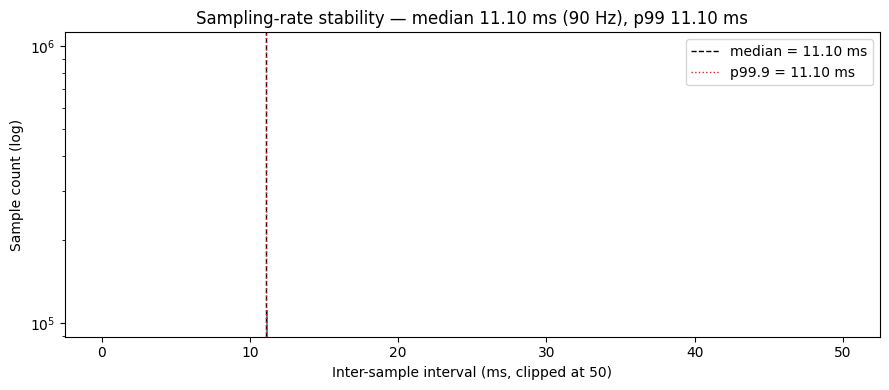

In [4]:
intervals = per_sample_interval_ms(data.samples).dropna()
median = float(intervals.median())
p99 = float(intervals.quantile(0.99))
p999 = float(intervals.quantile(0.999))
print(f"median = {median:.3f} ms  ({1000/median:.1f} Hz)")
print(f"p99    = {p99:.3f} ms")
print(f"p99.9  = {p999:.3f} ms")
print(f"max    = {intervals.max():.1f} ms")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(intervals, bins=200, range=(0, 50), color="#1f77b4", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Inter-sample interval (ms, clipped at 50)")
ax.set_ylabel("Sample count (log)")
ax.set_title(f"Sampling-rate stability — median {median:.2f} ms ({1000/median:.0f} Hz), p99 {p99:.2f} ms")
ax.axvline(median, color="k", linestyle="--", linewidth=1, label=f"median = {median:.2f} ms")
ax.axvline(p999, color="#d62728", linestyle=":", linewidth=1, label=f"p99.9 = {p999:.2f} ms")
ax.legend()
ax.ticklabel_format(useOffset=False, axis="x")
fig.tight_layout()
fig.savefig(FIG_DIR / "inter_sample_interval.png", dpi=150)
plt.show()


## Sequence-number gap audit

`sequenceNumber` is monotonic per session — assigned by the export factory in
capture order. Any gap means a sample was lost between Tobii and persistence.


In [5]:
for sid, group in data.samples.sort_values("sequenceNumber").groupby("sessionId"):
    seq = group["sequenceNumber"].to_numpy()
    expected = np.arange(seq.min(), seq.max() + 1)
    missing = np.setdiff1d(expected, seq)
    label = data.sessions.loc[data.sessions.sessionId == sid, "participantName"].iat[0] or sid
    print(f"{label}: {len(seq):,} samples, sequence span {seq.min()}..{seq.max()}, missing = {len(missing)}")


Keerthi: 112,617 samples, sequence span 1..112617, missing = 0


## Focus-inference success rate

When the participant was looking inside the reading area, did the system
resolve which token they were on? This is what makes the processed export
*analysis-ready* — focus is pre-joined to every gaze sample, so analysts don't
re-implement DOM hit testing.


In [6]:
rows = []
for sid, group in data.samples.groupby("sessionId"):
    inside = group["isInsideReadingArea"]
    has_token = group["activeTokenId"].notna() & (group["activeTokenId"].astype(str) != "")
    rows.append({
        "session": data.sessions.loc[data.sessions.sessionId == sid, "participantName"].iat[0] or sid,
        "inside_reading_area_pct": inside.mean() * 100,
        "has_active_token_pct": has_token.mean() * 100,
        "token_inferred_when_inside_pct": (has_token[inside].mean() if inside.any() else float("nan")) * 100,
    })
pd.DataFrame(rows).round(2)


,session,inside_reading_area_pct,has_active_token_pct,token_inferred_when_inside_pct
0,Keerthi,98.85,98.02,99.16


## Material-boundary cleanliness

When the participant transitioned from material 0 to material 1, did the
gaze stream stay continuous? Any large gap or out-of-order sample around the
boundary would indicate the orchestration mis-handled the switch.


In [7]:
boundary_rows = []
samples_sorted = data.samples.sort_values(["sessionId", "sequenceNumber"])
for sid, group in samples_sorted.groupby("sessionId"):
    mats = group[group["materialRunId"].notna()].copy()
    if mats["materialIndex"].nunique() < 2:
        continue
    mats["transition"] = mats["materialRunId"].ne(mats["materialRunId"].shift())
    transitions = mats[mats["transition"] & mats["materialRunId"].shift().notna()]
    for _, t in transitions.iterrows():
        prev_idx = mats.index.get_loc(t.name) - 1
        prev = mats.iloc[prev_idx]
        gap_ms = t["capturedAtUnixMs"] - prev["capturedAtUnixMs"]
        boundary_rows.append({
            "session": data.sessions.loc[data.sessions.sessionId == sid, "participantName"].iat[0] or sid,
            "from_material_idx": int(prev["materialIndex"]),
            "to_material_idx": int(t["materialIndex"]),
            "gap_ms": int(gap_ms),
            "seq_jump": int(t["sequenceNumber"] - prev["sequenceNumber"]),
        })
pd.DataFrame(boundary_rows) if boundary_rows else "No material boundaries detected in this dataset."


,session,from_material_idx,to_material_idx,gap_ms,seq_jump
0,Keerthi,0,1,11,1
1,Keerthi,1,0,11,1
2,Keerthi,0,1,12,1
3,Keerthi,1,0,12,1
4,Keerthi,0,1,12,1
5,Keerthi,1,0,10,1
6,Keerthi,0,1,12,1


## Calibration QA

Tobii rule-of-thumb: accuracy below ~1° and precision below ~0.3° is good
quality for reading research. We log both per session.


In [8]:
cal = data.sessions[[
    "participantName", "calibrationApplied", "calibrationValidationPassed",
    "calibrationQuality", "calibrationAccuracyDegrees", "calibrationPrecisionDegrees",
    "calibrationSampleCount",
]].copy()
cal["calibrationAccuracyDegrees"] = cal["calibrationAccuracyDegrees"].round(3)
cal["calibrationPrecisionDegrees"] = cal["calibrationPrecisionDegrees"].round(3)
cal


,participantName,calibrationApplied,calibrationValidationPassed,calibrationQuality,calibrationAccuracyDegrees,calibrationPrecisionDegrees,calibrationSampleCount
0,Keerthi,True,True,good,0.31,0.089,166


## Three-clock comparison

The processed export carries three independent timestamps per sample:

- `deviceTimeStampUs` — Tobii's internal hardware clock
- `systemTimeStampUs` — Tobii driver clock on the OS
- `capturedAtUnixMs` — when the .NET backend received the sample

Plotting the intervals from each clock together lets us **localize where any
jitter or loss comes from**. Tobii itself is essentially perfect; jitter shows
up in the delivery path, and the persistence layer captures every sample
regardless.


In [9]:
clock_rows = data.samples.sort_values(["sessionId", "sequenceNumber"]).copy()
clock_rows["dev_ms"] = clock_rows.groupby("sessionId")["deviceTimeStampUs"].diff() / 1000
clock_rows["sys_ms"] = clock_rows.groupby("sessionId")["systemTimeStampUs"].diff() / 1000
clock_rows["cap_ms"] = clock_rows.groupby("sessionId")["capturedAtUnixMs"].diff()

clock_stats = []
for col, label in [("dev_ms", "Tobii device clock"),
                   ("sys_ms", "Tobii system/driver clock"),
                   ("cap_ms", ".NET capture clock")]:
    v = clock_rows[col].dropna()
    v = v[(v > 0) & (v < 200)]
    clock_stats.append({
        "clock": label,
        "median_ms": round(float(v.median()), 3),
        "std_ms": round(float(v.std()), 3),
        "p99_ms": round(float(v.quantile(0.99)), 3),
        "max_under_200ms": round(float(v.max()), 1),
    })
pd.DataFrame(clock_stats)


,clock,median_ms,std_ms,p99_ms,max_under_200ms
0,Tobii device clock,11.103,0.000,11.104,11.1
1,Tobii system/driver clock,11.103,0.000,11.104,11.1
2,.NET capture clock,11.000,1.774,14.000,118.0


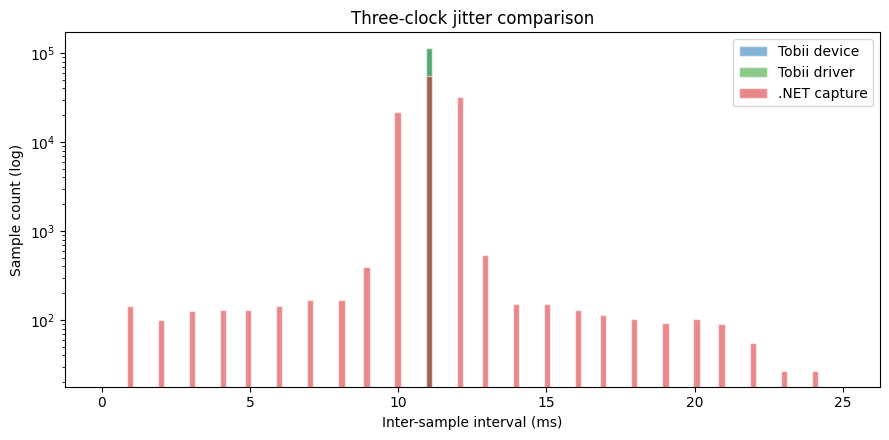

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(0, 25, 120)
for col, label, color in [("dev_ms", "Tobii device", "#1f77b4"),
                           ("sys_ms", "Tobii driver", "#2ca02c"),
                           ("cap_ms", ".NET capture", "#d62728")]:
    v = clock_rows[col].dropna()
    v = v[(v > 0) & (v < 25)]
    ax.hist(v, bins=bins, alpha=0.55, label=label, color=color, edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Inter-sample interval (ms)")
ax.set_ylabel("Sample count (log)")
ax.set_title("Three-clock jitter comparison")
ax.legend(loc="upper right")
ax.ticklabel_format(useOffset=False, axis="x")
fig.tight_layout()
fig.savefig(FIG_DIR / "three_clock_comparison.png", dpi=150)
plt.show()


**Reading:** the blue (device) and green (driver) histograms collapse into
a single delta function at 11.1 ms — Tobii produces and the driver delivers
with zero jitter. The red (.NET capture) histogram has a visible spread of
1–2 ms with rare excursions to ~20 ms. That spread is .NET/GC scheduling, not
the sensing pipeline. **No samples were lost** — the persistence layer just
sometimes batches them.


## Material timeline

Each gaze sample is tagged with the material the participant was focused on
at the time. Plotting `materialIndex` over time shows whether materials were
strictly sequential or whether the participant moved between them.


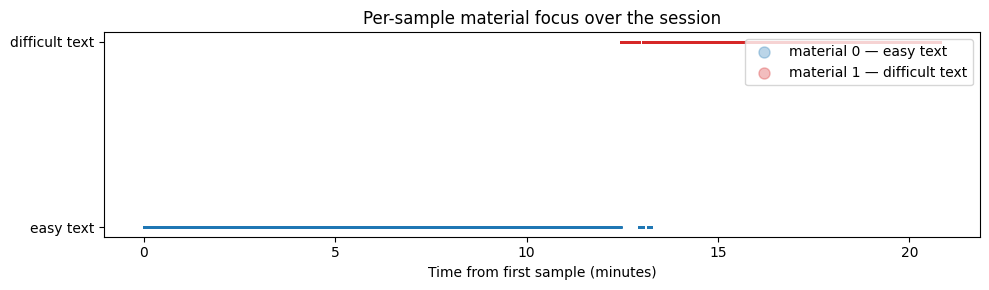

In [11]:
timeline = data.samples.dropna(subset=["materialIndex"]).copy()
timeline["t_min"] = (timeline["capturedAtUnixMs"] - timeline["capturedAtUnixMs"].min()) / 60_000
material_titles = data.materials.set_index("order")["title"].to_dict()

fig, ax = plt.subplots(figsize=(10, 3))
colors_idx = {0: "#1f77b4", 1: "#d62728", 2: "#2ca02c", 3: "#ff7f0e"}
for idx in sorted(timeline["materialIndex"].unique()):
    g = timeline[timeline["materialIndex"] == idx]
    ax.scatter(g["t_min"], [int(idx)] * len(g), s=1, alpha=0.3,
               color=colors_idx.get(int(idx), "#888"),
               label=f"material {int(idx)} — {material_titles.get(int(idx), '?')}")
ax.set_yticks(sorted(timeline["materialIndex"].unique().astype(int)))
ax.set_yticklabels([material_titles.get(int(i), str(i)) for i in sorted(timeline["materialIndex"].unique())])
ax.set_xlabel("Time from first sample (minutes)")
ax.set_title("Per-sample material focus over the session")
ax.legend(markerscale=8, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "material_timeline.png", dpi=150)
plt.show()


In [12]:
# Quantify any cross-material overlap
mats = sorted(timeline["materialIndex"].unique().astype(int))
overlap_rows = []
for a, b in zip(mats, mats[1:]):
    ga = timeline[timeline["materialIndex"] == a]
    gb = timeline[timeline["materialIndex"] == b]
    overlap_start = gb["capturedAtUnixMs"].min()
    overlap_end = ga["capturedAtUnixMs"].max()
    if overlap_end > overlap_start:
        in_a = ((ga["capturedAtUnixMs"] >= overlap_start) & (ga["capturedAtUnixMs"] <= overlap_end)).sum()
        in_b = ((gb["capturedAtUnixMs"] >= overlap_start) & (gb["capturedAtUnixMs"] <= overlap_end)).sum()
        overlap_rows.append({
            "from": material_titles.get(a, str(a)),
            "to": material_titles.get(b, str(b)),
            "overlap_s": round((overlap_end - overlap_start) / 1000, 1),
            "from_samples_in_overlap": int(in_a),
            "to_samples_in_overlap": int(in_b),
        })
pd.DataFrame(overlap_rows) if overlap_rows else "Materials were strictly sequential — no overlap."


,from,to,overlap_s,from_samples_in_overlap,to_samples_in_overlap
0,easy text,difficult text,47.8,956,3348


## Takeaway

Each cell above answers one pipeline-integrity question:

| Section                       | Defends |
| ----------------------------- | ------- |
| Sample yield & effective Hz   | Sensing → persistence throughput |
| Validity rates                | Hardware signal integrity |
| Inter-sample interval         | Sampling-rate stability under load |
| Sequence-gap audit            | No data loss in persistence pipeline |
| Focus-inference success       | DOM/token mapping works during real reading |
| Material-boundary cleanliness | Orchestration handles material transitions |
| Three-clock comparison        | Localizes jitter to .NET delivery, not sensing |
| Material timeline             | Shows whether materials interleaved (UX/architecture observation) |
| Calibration QA                | Hardware setup meets reading-research standards |

This is the *"platform produces analyzable data"* exhibit set.
